# The Case for Regulating Private Credit -- Companion Charts

Reproducible data and code for every chart in the Ahmadi Research thematic post
**"The Case for Regulating Private Credit: How a $2.3 Trillion Industry Outgrew Its Oversight."**

- Live post: https://ahmadiresearch.com/blog/regulating-private-credit/ (forthcoming)
- Author: Mohammad Ahmadi

This notebook regenerates every chart from the post in matplotlib. Every data
point is cited inline. Every assumption is written down. Change the inputs,
rerun, and see what breaks.

> *"If someone with the same data can't get to the same conclusion, the analysis isn't done."*


## Setup

```bash
pip install -r requirements.txt
jupyter notebook "Blue_Owl_Charts.ipynb"
```

Dependencies: `pandas`, `numpy`, `matplotlib`. No proprietary data, no black boxes.
The cells share one brand palette and one set of `rcParams`; everything below
runs against that.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.path import Path as MPath
from datetime import datetime
import textwrap

# Brand palette (matches Ahmadi Research site and the deck exactly)
BLUE_DEEP   = "#02223c"
BLUE_MAIN   = "#005a96"
BLUE_SOFT   = "#0f80c4"
BLUE_LIGHT  = "#8fd1ff"
BLUE_MUTED  = "#d8e7f5"
TITLE_BLUE  = "#13597B"
TEXT_MAIN   = "#0f172a"
TEXT_MUTED  = "#4b5563"
GRAY_DARK   = "#6b7280"
GRAY_MID    = "#9ca3af"
GRAY_LIGHT  = "#d1d5db"
GREEN       = "#22c55e"
RED_SOFT    = "#dc2626"
NAVY_TEAL   = "#2c6a84"
CRIMSON     = "#b91c1c"

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Garamond", "Georgia", "Times New Roman", "serif"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     TEXT_MUTED,
    "xtick.color":        TEXT_MAIN,
    "ytick.color":        TEXT_MAIN,
    "text.color":         TEXT_MAIN,
    "text.parse_math":    False,
})

def watermark(fig, text="Ahmadi Research  |  ahmadiresearch.com"):
    fig.text(0.99, 0.01, text, ha="right", va="bottom",
             fontsize=7.5, color=TEXT_MUTED, style="italic")


---

## Chart 1 -- Private Credit: A 40-Year Timeline

From 1980s niche to a $2.3T asset class. Three eras (Origins, Post-GFC
Expansion, Democratization) marked by eleven milestones. Private credit's
rise is not one event. It is a forty-year accumulation of statute and
market structure that moved leveraged lending off bank balance sheets.

**Sources**

- Preqin Global Private Debt Reports (annual). Core AUM trajectory.
- McKinsey Global Private Markets Review (2024 and 2025 editions). Era framing.
- SEC EDGAR. Ares Capital S-1 (2004); Blue Owl Capital 10-K (FY2025).
- Small Business Investment Incentive Act of 1980 (P.L. 96-477). BDC structure.

**Assumptions you can argue with**
1. Era boundaries (2008, 2021) are pinned to the GFC and Blue Owl SPAC merger.
   You could equally pin the second boundary to 2018-2020 (the rise of
   semi-liquid BDCs).
2. The "first redemption stress" milestone is dated 2025 because Q4 2025 is
   when OBDC II's merger collapsed and the cap-then-restrict pattern began.
   Earlier minor redemption events at peer funds aren't on this timeline.


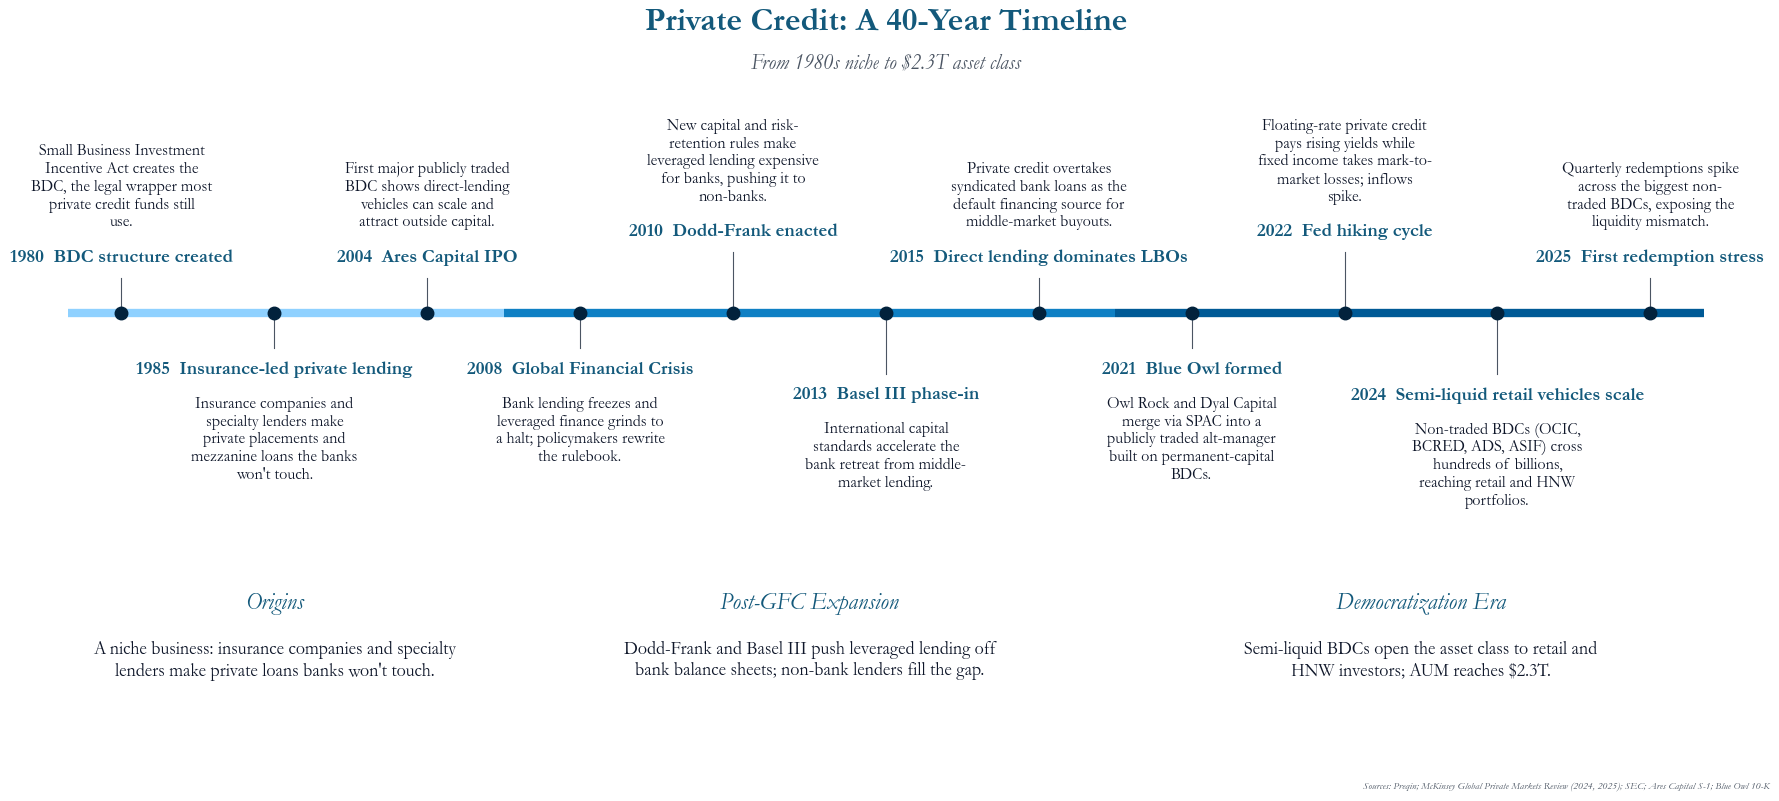

In [2]:
# Milestones: (year, short_title, description, vertical_offset)
milestones = [
    (1980, "BDC structure created",
     "Small Business Investment Incentive Act creates the BDC, the legal wrapper most private credit funds still use.",
     +0.6),
    (1985, "Insurance-led private lending",
     "Insurance companies and specialty lenders make private placements and mezzanine loans the banks won't touch.",
     -0.6),
    (2004, "Ares Capital IPO",
     "First major publicly traded BDC shows direct-lending vehicles can scale and attract outside capital.",
     +0.6),
    (2008, "Global Financial Crisis",
     "Bank lending freezes and leveraged finance grinds to a halt; policymakers rewrite the rulebook.",
     -0.6),
    (2010, "Dodd-Frank enacted",
     "New capital and risk-retention rules make leveraged lending expensive for banks, pushing it to non-banks.",
     +1.1),
    (2013, "Basel III phase-in",
     "International capital standards accelerate the bank retreat from middle-market lending.",
     -1.1),
    (2015, "Direct lending dominates LBOs",
     "Private credit overtakes syndicated bank loans as the default financing source for middle-market buyouts.",
     +0.6),
    (2021, "Blue Owl formed",
     "Owl Rock and Dyal Capital merge via SPAC into a publicly traded alt-manager built on permanent-capital BDCs.",
     -0.6),
    (2022, "Fed hiking cycle",
     "Floating-rate private credit pays rising yields while fixed income takes mark-to-market losses; inflows spike.",
     +1.1),
    (2024, "Semi-liquid retail vehicles scale",
     "Non-traded BDCs (OCIC, BCRED, ADS, ASIF) cross hundreds of billions, reaching retail and HNW portfolios.",
     -1.1),
    (2025, "First redemption stress",
     "Quarterly redemptions spike across the biggest non-traded BDCs, exposing the liquidity mismatch.",
     +0.6),
]

eras = [
    (1980, 2008, BLUE_LIGHT, "Origins",
     "A niche business: insurance companies and specialty lenders make private loans banks won't touch."),
    (2008, 2021, BLUE_SOFT,  "Post-GFC Expansion",
     "Dodd-Frank and Basel III push leveraged lending off bank balance sheets; non-bank lenders fill the gap."),
    (2021, 2026, BLUE_MAIN,  "Democratization Era",
     "Semi-liquid BDCs open the asset class to retail and HNW investors; AUM reaches $2.3T."),
]

fig, ax = plt.subplots(figsize=(18, 8))
for spine in ax.spines.values():
    spine.set_visible(False)

slots = {year: i for i, (year, *_) in enumerate(milestones)}
n = len(milestones)

def slot_for_year(yr):
    years = [m[0] for m in milestones]
    for i, yy in enumerate(years):
        if yr <= yy:
            return i - 0.5 if i > 0 else -0.5
    return len(years) - 0.5

for start, end, color, *_ in eras:
    x0 = slot_for_year(start); x1 = slot_for_year(end)
    ax.plot([x0, x1], [0, 0], color=color, linewidth=6, solid_capstyle="butt", zorder=1)

for start, end, color, label, desc in eras:
    x0 = slot_for_year(start); x1 = slot_for_year(end)
    mid = (x0 + x1) / 2
    ax.text(mid, -1.75, label, ha="center", va="top",
            fontsize=17, color=TITLE_BLUE, style="italic", fontweight="bold")
    wrapped = "\n".join(textwrap.wrap(desc, width=52))
    ax.text(mid, -2.05, wrapped, ha="center", va="top",
            fontsize=13, color=TEXT_MAIN, linespacing=1.25)

for year, title, desc, offset in milestones:
    x = slots[year]
    ax.plot(x, 0, "o", markersize=9, color=BLUE_DEEP, zorder=3)
    sign = 1 if offset > 0 else -1
    stem_end = 0.35 * sign * (abs(offset) ** 0.9)
    ax.plot([x, x], [0, stem_end], color=TEXT_MUTED, linewidth=0.8, zorder=2)
    va = "bottom" if sign > 0 else "top"
    title_y = stem_end + 0.08 * sign
    ax.text(x, title_y, f"{year}  {title}", ha="center", va=va,
            fontsize=13.5, color=TITLE_BLUE, fontweight="bold", linespacing=1.15)
    wrapped = "\n".join(textwrap.wrap(desc, width=28))
    desc_y = title_y + sign * 0.22
    ax.text(x, desc_y, wrapped, ha="center", va=va,
            fontsize=11.5, color=TEXT_MAIN, linespacing=1.25)

ax.text(0.5, 1.05, "Private Credit: A 40-Year Timeline",
        transform=ax.transAxes, ha="center", va="bottom",
        fontsize=24, color=TITLE_BLUE, fontweight="bold")
ax.text(0.5, 1.00, "From 1980s niche to $2.3T asset class",
        transform=ax.transAxes, ha="center", va="bottom",
        fontsize=15, color=TEXT_MUTED, style="italic")

ax.set_xlim(-0.35, n - 0.65)
ax.set_ylim(-2.95, 1.5)
ax.set_yticks([]); ax.set_xticks([])

fig.text(0.99, 0.01,
         "Sources: Preqin; McKinsey Global Private Markets Review (2024, 2025); SEC; Ares Capital S-1; Blue Owl 10-K",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")

plt.tight_layout()
plt.show()


---

## Chart 2 -- How Private Credit Works

A four-node flow diagram: capital providers (institutional and retail) put
money into the asset manager (the GP), which raises the BDC or fund vehicle,
which lends to middle-market borrowers and pays distributions back. Fees
flow from the BDC to the manager. This is the basic plumbing every private
credit fund runs on, regardless of size.

**Sources**

- Generic structural diagram of a Business Development Company (BDC) under
  the Investment Company Act of 1940 and the Small Business Investment
  Incentive Act of 1980.
- Blue Owl Capital 10-K (FY2025); Ares Capital 10-K; Apollo Debt Solutions
  prospectus. All five named managers operate variants of this exact structure.


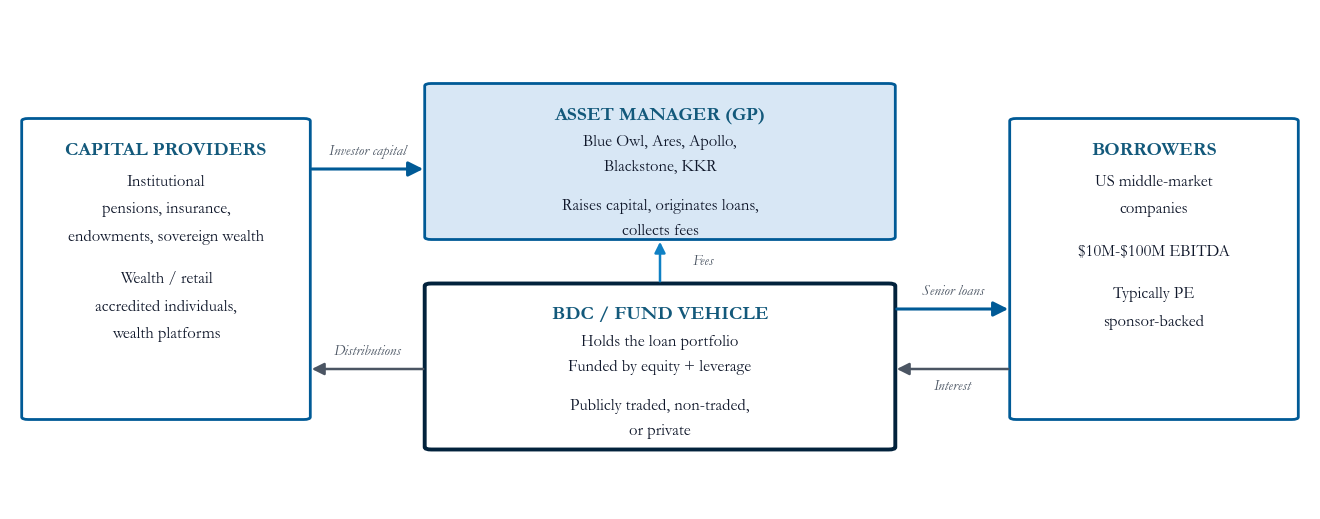

In [3]:
fig = plt.figure(figsize=(13, 5))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

FS_BOX_HDR, FS_BODY, FS_ARROW = 14, 12, 11

def flow_box(x, y, w, h, header, bullets, facecolor="white",
             edgecolor=BLUE_MAIN, lw=2.0, header_color=TITLE_BLUE,
             first_gap=11, line_gap=5.0, blank_gap=3.0):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1,rounding_size=0.5",
                       linewidth=lw, edgecolor=edgecolor, facecolor=facecolor)
    ax.add_patch(b)
    ax.text(x + w/2, y + h - 4.5, header, ha="center", va="top",
            fontsize=FS_BOX_HDR, color=header_color, fontweight="bold")
    y_cursor = y + h - first_gap
    for line in bullets:
        if line == "":
            y_cursor -= blank_gap; continue
        ax.text(x + w/2, y_cursor, line, ha="center", va="top",
                fontsize=FS_BODY, color=TEXT_MAIN, linespacing=1.25)
        y_cursor -= line_gap

flow_box(1, 18, 22, 60, "CAPITAL PROVIDERS",
         ["Institutional", "pensions, insurance,",
          "endowments, sovereign wealth", "",
          "Wealth / retail", "accredited individuals,", "wealth platforms"],
         first_gap=11, line_gap=5.5, blank_gap=3.0)

flow_box(32, 54, 36, 31, "ASSET MANAGER (GP)",
         ["Blue Owl, Ares, Apollo,", "Blackstone, KKR", "",
          "Raises capital, originates loans,", "collects fees"],
         facecolor=BLUE_MUTED, first_gap=10, line_gap=5.0, blank_gap=2.8)

flow_box(32, 12, 36, 33, "BDC / FUND VEHICLE",
         ["Holds the loan portfolio", "Funded by equity + leverage", "",
          "Publicly traded, non-traded,", "or private"],
         edgecolor=BLUE_DEEP, lw=2.8, first_gap=10, line_gap=5.0, blank_gap=2.8)

flow_box(77, 18, 22, 60, "BORROWERS",
         ["US middle-market", "companies", "",
          "$10M-$100M EBITDA", "", "Typically PE", "sponsor-backed"],
         first_gap=11, line_gap=5.5, blank_gap=3.0)

ax.annotate("", xy=(32, 68), xytext=(23, 68),
            arrowprops=dict(arrowstyle="-|>", color=BLUE_MAIN, lw=2.2, mutation_scale=22))
ax.text(27.5, 71, "Investor capital", ha="center", fontsize=FS_ARROW, color=TEXT_MUTED, style="italic")

ax.annotate("", xy=(23, 28), xytext=(32, 28),
            arrowprops=dict(arrowstyle="-|>", color=TEXT_MUTED, lw=1.8, mutation_scale=18))
ax.text(27.5, 31, "Distributions", ha="center", fontsize=FS_ARROW, color=TEXT_MUTED, style="italic")

ax.annotate("", xy=(77, 40), xytext=(68, 40),
            arrowprops=dict(arrowstyle="-|>", color=BLUE_MAIN, lw=2.2, mutation_scale=22))
ax.text(72.5, 43, "Senior loans", ha="center", fontsize=FS_ARROW, color=TEXT_MUTED, style="italic")

ax.annotate("", xy=(68, 28), xytext=(77, 28),
            arrowprops=dict(arrowstyle="-|>", color=TEXT_MUTED, lw=1.8, mutation_scale=18))
ax.text(72.5, 24, "Interest", ha="center", fontsize=FS_ARROW, color=TEXT_MUTED, style="italic")

ax.annotate("", xy=(50, 54), xytext=(50, 45),
            arrowprops=dict(arrowstyle="-|>", color=BLUE_SOFT, lw=1.8, mutation_scale=16))
ax.text(52.5, 49.5, "Fees", ha="left", va="center", fontsize=FS_ARROW, color=TEXT_MUTED, style="italic")

plt.show()


---

## Chart 3 -- The Private Credit Promise

Four cards laying out what private credit is sold as: stable returns, quarterly
liquidity, institutional-grade access for retail, and floating-rate yields that
benefit from a hiking cycle. These are the marketing claims the rest of the
post tests against the data.

**Sources**

- Cliffwater Direct Lending Index (CDLI), 2010-2024 annualized returns ~9%.
- Investment Company Act 1940 §23(c) and standard share repurchase programs:
  the typical 5%-of-NAV-per-quarter cap on semi-liquid BDCs is a fund-level
  prospectus disclosure, not a statutory cap.
- Robert A. Stanger & Co.; Morningstar non-traded fund AUM data, 2015 to 2025.
- LSEG LPC / PitchBook LCD direct lending spread data (typical SOFR + 500-700 bps).

**What's not on this card**

The Sharpe ratio of "near 1.8" comes from CDLI's reported risk-adjusted
returns. It is computed against a smoothed, appraisal-based NAV series, not a
mark-to-market series, so apples-to-apples comparisons against public credit
indices overstate the smoothing benefit. That is a feature of how non-traded
BDCs and CDLI are structured, not an analytical error.


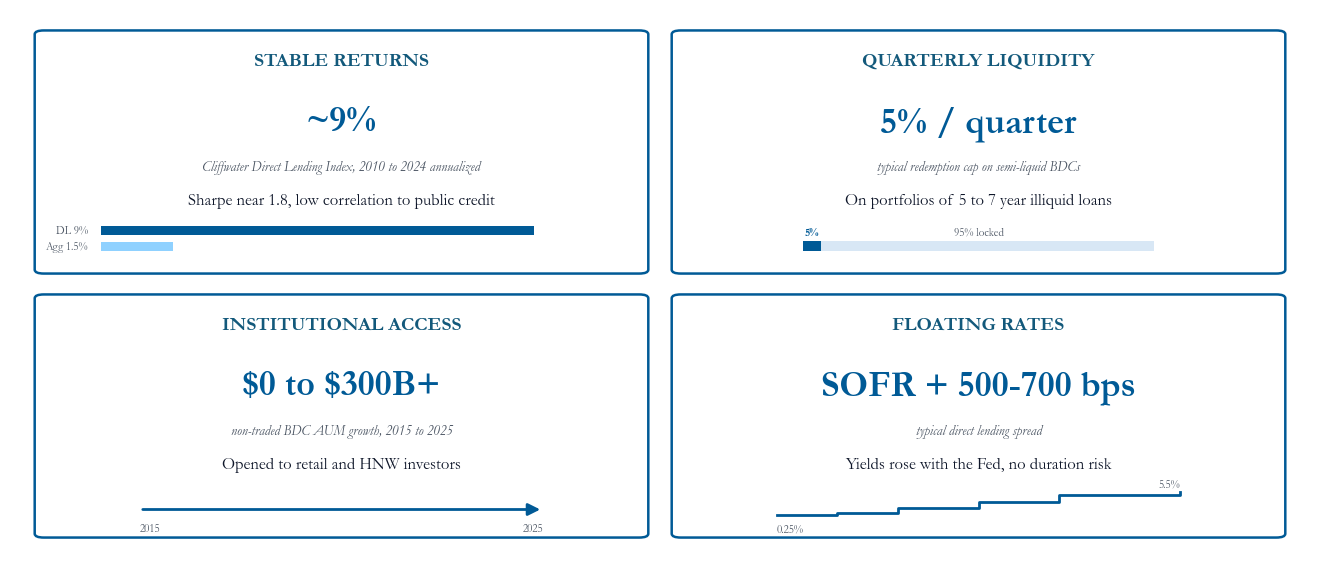

In [4]:
fig = plt.figure(figsize=(13, 5.5))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

FS_CARD_HDR, FS_STAT, FS_BODY, FS_CAPTION = 14, 26, 12, 10

def card(x, y, w, h, name, stat, proof, body_line,
         facecolor="white", edgecolor=BLUE_MAIN, lw=1.8, mini=None):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1,rounding_size=0.7",
                       linewidth=lw, edgecolor=edgecolor, facecolor=facecolor)
    ax.add_patch(b)
    ax.text(x + w/2, y + h - 4, name, ha="center", va="top",
            fontsize=FS_CARD_HDR, color=TITLE_BLUE, fontweight="bold")
    ax.text(x + w/2, y + h*0.62, stat, ha="center", va="center",
            fontsize=FS_STAT, color=BLUE_MAIN, fontweight="bold")
    ax.text(x + w/2, y + h*0.44, proof, ha="center", va="center",
            fontsize=FS_CAPTION, color=TEXT_MUTED, style="italic")
    if body_line:
        ax.text(x + w/2, y + h*0.30, body_line, ha="center", va="center",
                fontsize=FS_BODY, color=TEXT_MAIN, linespacing=1.3)
    if mini:
        mini(x, y, w, h)

def mini_bars(x, y, w, h):
    base_y = y + 4; bar_h = 1.6; left = x + 5; max_w = w - 10
    ax.add_patch(Rectangle((left, base_y + 3), max_w * (9/10), bar_h, facecolor=BLUE_MAIN, edgecolor="none"))
    ax.text(left - 1, base_y + 3 + bar_h/2, "DL 9%", ha="right", va="center", fontsize=8, color=TEXT_MUTED)
    ax.add_patch(Rectangle((left, base_y), max_w * (1.5/10), bar_h, facecolor=BLUE_LIGHT, edgecolor="none"))
    ax.text(left - 1, base_y + bar_h/2, "Agg 1.5%", ha="right", va="center", fontsize=8, color=TEXT_MUTED)

def mini_gauge(x, y, w, h):
    base_y = y + 4; bar_h = 1.8; left = x + 10; width = w - 20
    ax.add_patch(Rectangle((left, base_y), width * 0.05, bar_h, facecolor=BLUE_MAIN, edgecolor="none"))
    ax.add_patch(Rectangle((left + width*0.05, base_y), width*0.95, bar_h, facecolor=BLUE_MUTED, edgecolor="none"))
    ax.text(left + width*0.025, base_y + bar_h + 0.6, "5%", ha="center", va="bottom",
            fontsize=8, color=BLUE_MAIN, fontweight="bold")
    ax.text(left + width*0.5, base_y + bar_h + 0.6, "95% locked", ha="center", va="bottom",
            fontsize=8, color=TEXT_MUTED)

def mini_arrow(x, y, w, h):
    base_y = y + 5; left = x + 8; right = x + w - 8
    ax.annotate("", xy=(right, base_y), xytext=(left, base_y),
                arrowprops=dict(arrowstyle="-|>", color=BLUE_MAIN, lw=2.0, mutation_scale=18))
    ax.text(left, base_y - 2.5, "2015", ha="left", va="top", fontsize=8, color=TEXT_MUTED)
    ax.text(right, base_y - 2.5, "2025", ha="right", va="top", fontsize=8, color=TEXT_MUTED)

def mini_steps(x, y, w, h):
    base_y = y + 4; left = x + 8; right = x + w - 8
    xs = [left, left + (right-left)*0.15, left + (right-left)*0.3,
          left + (right-left)*0.5, left + (right-left)*0.7, right]
    ys_offsets = [0, 0.4, 1.2, 2.4, 3.6, 4.2]
    ys = [base_y + o for o in ys_offsets]
    ax.plot(xs, ys, color=BLUE_MAIN, lw=2.0, drawstyle="steps-post")
    ax.text(left, base_y - 1.5, "0.25%", ha="left", va="top", fontsize=8, color=TEXT_MUTED)
    ax.text(right, ys[-1] + 0.5, "5.5%", ha="right", va="bottom", fontsize=8, color=TEXT_MUTED)

card(2, 52, 47, 44, "STABLE RETURNS", "~9%",
     "Cliffwater Direct Lending Index, 2010 to 2024 annualized",
     "Sharpe near 1.8, low correlation to public credit", mini=mini_bars)
card(51, 52, 47, 44, "QUARTERLY LIQUIDITY", "5% / quarter",
     "typical redemption cap on semi-liquid BDCs",
     "On portfolios of 5 to 7 year illiquid loans", mini=mini_gauge)
card(2, 4, 47, 44, "INSTITUTIONAL ACCESS", "$0 to $300B+",
     "non-traded BDC AUM growth, 2015 to 2025",
     "Opened to retail and HNW investors", mini=mini_arrow)
card(51, 4, 47, 44, "FLOATING RATES", "SOFR + 500-700 bps",
     "typical direct lending spread",
     "Yields rose with the Fed, no duration risk", mini=mini_steps)

plt.show()


---

## Chart 4 -- Private Credit AUM Growth, 2010-2025

Global private credit AUM from $300B in 2010 to ~$2.3T in 2025. Annotated
with the policy and rate-cycle shifts that pushed lending off bank balance
sheets and onto private fund balance sheets.

**Sources**

- Preqin Global Private Debt Reports (annual). Series spine 2010-2024.
- McKinsey Global Private Markets Review (2024 and 2025 editions). 2025 ~$2.3T.

**Assumptions you can argue with**
1. The 2025 figure is mid-year/projected. Different industry trackers report
   year-end 2025 between $2.0T and $2.5T depending on definition (dry powder
   in / out, fund-of-funds in / out, BDCs in / out).
2. Annotation dates for "Dodd-Frank / Basel III push" are coarse: the bank
   retreat happened in stages from 2010 to 2018, not in a single year.


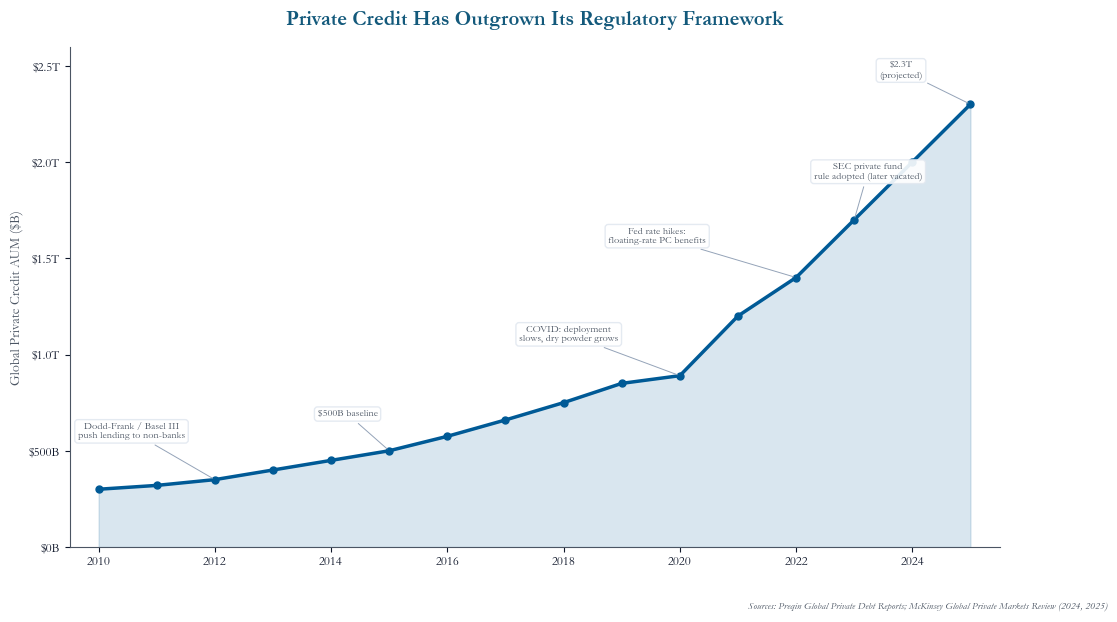

In [5]:
years = list(range(2010, 2026))
aum =   [300, 320, 350, 400, 450, 500, 575, 660, 750, 850, 890, 1200, 1400, 1700, 2000, 2300]

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.fill_between(years, aum, alpha=0.15, color=BLUE_MAIN)
ax.plot(years, aum, color=BLUE_MAIN, linewidth=2.5, marker="o", markersize=5, zorder=3)

annotations = [
    (2012, 350, "Dodd-Frank / Basel III\npush lending to non-banks", (-60, 30)),
    (2015, 500, "$500B baseline", (-30, 25)),
    (2020, 890, "COVID: deployment\nslows, dry powder grows", (-80, 25)),
    (2022, 1400, "Fed rate hikes:\nfloating-rate PC benefits", (-100, 25)),
    (2023, 1700, "SEC private fund\nrule adopted (later vacated)", (10, 30)),
    (2025, 2300, "$2.3T\n(projected)", (-50, 20)),
]
for x, y, txt, offset in annotations:
    ax.annotate(txt, xy=(x, y), xytext=offset, textcoords="offset points",
                fontsize=7.5, color=TEXT_MUTED, ha="center",
                arrowprops=dict(arrowstyle="-", color="#94a3b8", lw=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e2e8f0", alpha=0.9))

ax.set_title("Private Credit Has Outgrown Its Regulatory Framework",
             fontsize=15, fontweight="bold", color=TITLE_BLUE, pad=16)
ax.set_ylabel("Global Private Credit AUM ($B)", fontsize=10, color=TEXT_MUTED)
ax.set_xlim(2009.5, 2025.5); ax.set_ylim(0, 2600)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.1f}T" if x >= 1000 else f"${x:.0f}B"))
ax.tick_params(axis="both", labelsize=9)

fig.text(0.99, 0.01, "Sources: Preqin Global Private Debt Reports; McKinsey Global Private Markets Review (2024, 2025)",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 5 -- Private Credit Share of LBO Financing, 2014-2024

Direct lending share of leveraged buyout financing. Middle market goes from
~36% in 2014 to ~90% in 2024. Large-LBO share (deals over $1B) climbs from
20% to 50% over the same window, with a 61% peak in 2023 when the
broadly-syndicated loan market was effectively closed.

**Sources**

- LSEG LPC (Loan Pricing Corporation), middle-market LBO financing data.
- PitchBook LCD, 2024 Direct Lending Review.
- ABF Journal / S&P Global, "Direct Lending and BSL Markets," 2014/2023/2024
  market share figures.


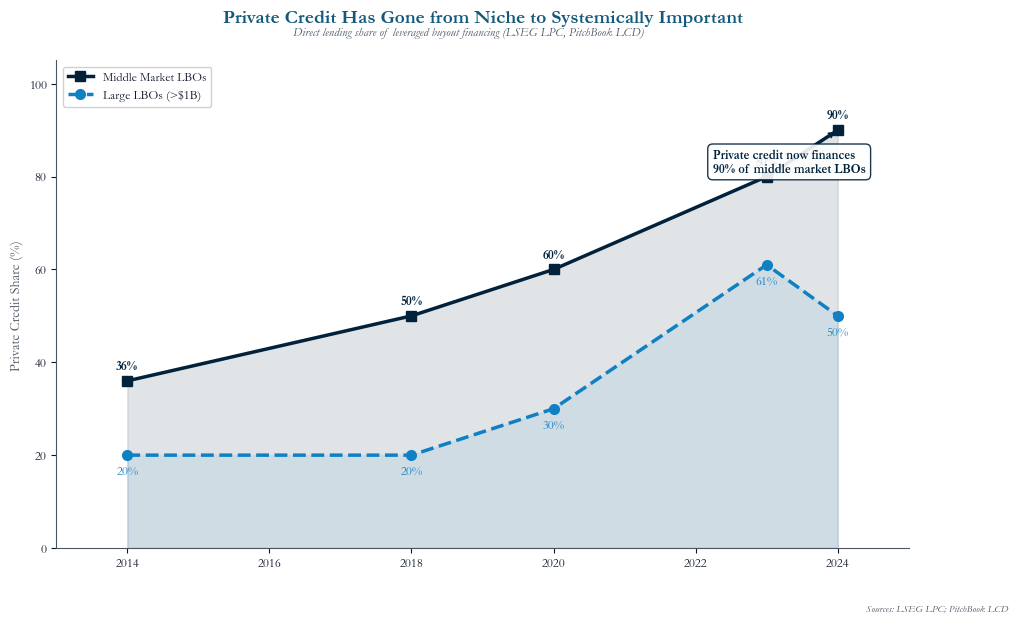

In [6]:
years5 = [2014, 2018, 2020, 2023, 2024]
mm_share = [36, 50, 60, 80, 90]
large_share = [20, 20, 30, 61, 50]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(years5, mm_share, color=BLUE_DEEP, linewidth=2.5, marker="s", markersize=7,
        label="Middle Market LBOs", zorder=3)
ax.plot(years5, large_share, color=BLUE_SOFT, linewidth=2.5, marker="o", markersize=7,
        label="Large LBOs (>$1B)", zorder=3, linestyle="--")
ax.fill_between(years5, mm_share, alpha=0.12, color=BLUE_DEEP)
ax.fill_between(years5, large_share, alpha=0.08, color=BLUE_SOFT)

for x, y in zip(years5, mm_share):
    ax.text(x, y + 2.5, f"{y}%", ha="center", fontsize=9, fontweight="bold", color=BLUE_DEEP)
for x, y in zip(years5, large_share):
    ax.text(x, y - 4, f"{y}%", ha="center", fontsize=9, color=BLUE_SOFT)

ax.annotate("Private credit now finances\n90% of middle market LBOs",
            xy=(2024, 90), xytext=(-90, -30), textcoords="offset points",
            fontsize=9, color=BLUE_DEEP, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=BLUE_DEEP, lw=1.2),
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=BLUE_DEEP, alpha=0.9))

ax.set_title("Private Credit Has Gone from Niche to Systemically Important",
             fontsize=14, fontweight="bold", color=TITLE_BLUE, pad=28)
ax.set_ylabel("Private Credit Share (%)", fontsize=10, color=TEXT_MUTED)
ax.set_ylim(0, 105); ax.set_xlim(2013, 2025)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.tick_params(axis="both", labelsize=9)

fig.subplots_adjust(top=0.86)
fig.text(0.5, 0.90, "Direct lending share of leveraged buyout financing (LSEG LPC, PitchBook LCD)",
         ha="center", fontsize=9, color=TEXT_MUTED, style="italic")
fig.text(0.99, 0.01, "Sources: LSEG LPC; PitchBook LCD",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 6 -- The Business Grew. The Stock Didn't.

Five Blue Owl metrics indexed to Dec 31, 2023: AUM, quarterly revenue, quarterly
EBITDA proxy, trailing-twelve-month Class A net income, and the OWL share price.
The fundamentals march up. The stock retraces almost entirely between January
2025 and April 2026.

**Sources**

- Blue Owl 10-K (FY2025); Q4 2025 Earnings Deck (Feb 5, 2026); quarterly
  earnings decks Q4'23 through Q4'25. AUM, revenue, operating income,
  amortization, Class A net income.
- Yahoo Finance (OWL daily closes). Quarterly closes plus April 2026 reading.

**Assumptions you can argue with**
1. EBITDA is a proxy: GAAP operating income + amortization of intangibles. Blue
   Owl reports "fee-related earnings" and "distributable earnings"; this proxy
   is intentionally GAAP-anchored.
2. TTM Class A NI for Q1 and Q2 2024 uses an estimated flat allocation for
   Q1-Q3 2023 (FY'23 Class A NI of $54.3M minus disclosed Q4'23 of $18.1M,
   spread evenly across the three earlier quarters at $12.07M each). All
   later TTM points are exact from disclosed quarterlies.


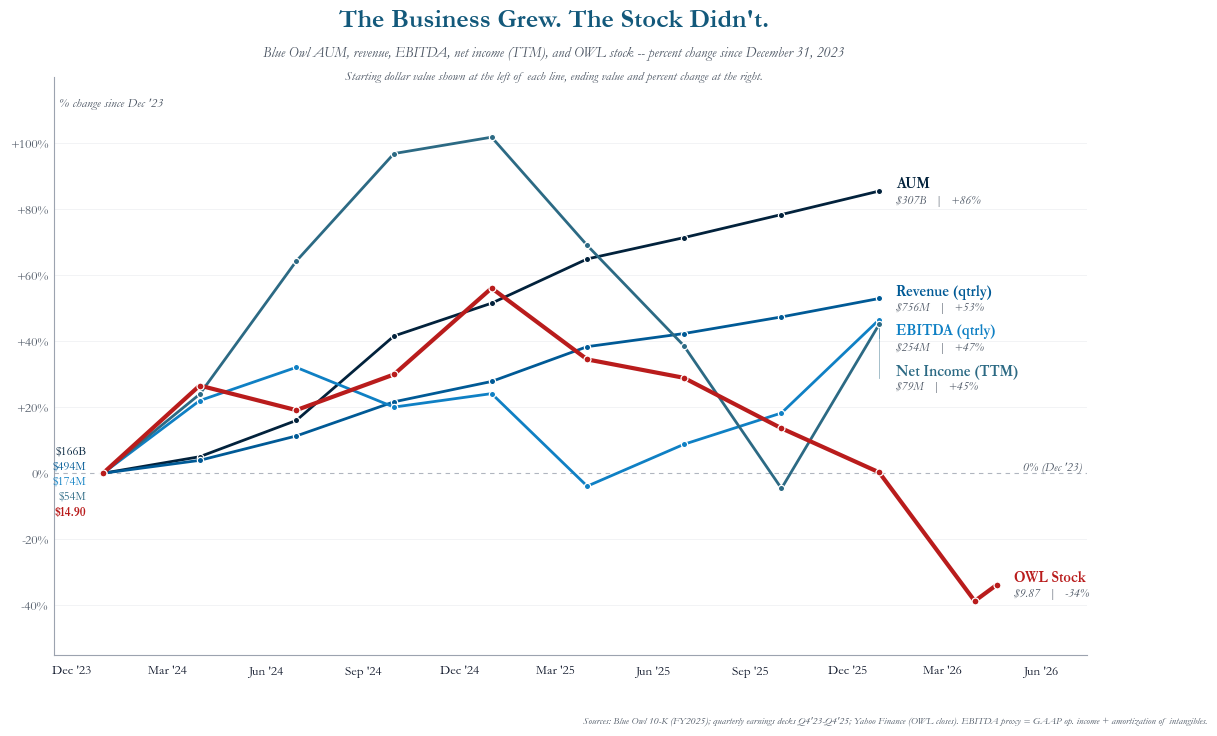

In [7]:
def d(s): return datetime.strptime(s, "%Y-%m-%d")

Q_DATES = [
    d("2023-12-31"), d("2024-03-31"), d("2024-06-30"), d("2024-09-30"),
    d("2024-12-31"), d("2025-03-31"), d("2025-06-30"), d("2025-09-30"),
    d("2025-12-31"),
]
AUM    = [165.7, 174.0, 192.2, 234.6, 251.1, 273.3, 284.0, 295.6, 307.4]
REV    = [494.0, 513.3, 549.8, 600.9, 631.4, 683.5, 703.1, 728.0, 755.6]
EBITDA = [173.6, 211.8, 229.3, 208.4, 215.5, 166.8, 188.8, 205.3, 254.4]
NI_TTM = [54.3, 67.3, 89.2, 106.9, 109.6, 91.8, 75.3, 51.8, 78.8]

STOCK_DATES = Q_DATES + [d("2026-03-31"), d("2026-04-21")]
STOCK_PX    = [14.90, 18.86, 17.75, 19.36, 23.26, 20.04, 19.21, 16.93, 14.94, 9.13, 9.87]

def pct(values):
    base = values[0]; return [(v/base - 1) * 100 for v in values]
def fmt_aum(v): return f"${v:.0f}B"
def fmt_rev(v): return f"${v/1000:.2f}B" if v >= 1000 else f"${v:,.0f}M"
def fmt_px(v):  return f"${v:.2f}"

SERIES = [
    ("AUM",              Q_DATES,     AUM,     fmt_aum, BLUE_DEEP),
    ("Revenue (qtrly)",  Q_DATES,     REV,     fmt_rev, BLUE_MAIN),
    ("EBITDA (qtrly)",   Q_DATES,     EBITDA,  fmt_rev, BLUE_SOFT),
    ("Net Income (TTM)", Q_DATES,     NI_TTM,  fmt_rev, NAVY_TEAL),
    ("OWL Stock",        STOCK_DATES, STOCK_PX,fmt_px,  CRIMSON),
]

fig, ax = plt.subplots(figsize=(13.33, 7.50))
ax.axhline(0, color=GRAY_MID, lw=0.8, linestyle=(0, (4, 4)), alpha=0.8, zorder=1)

rendered = []
for label, dates, values, fmt, color in SERIES:
    ys = pct(values); is_stock = label == "OWL Stock"
    ax.plot(dates, ys, color=color, lw=3.0 if is_stock else 2.0,
            marker="o", markersize=5 if is_stock else 4.5,
            markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.9,
            zorder=6 if is_stock else 4)
    rendered.append((label, dates, values, fmt, color, ys, is_stock))

START_VOFFSET = {
    "AUM":              (-12, 16),
    "Revenue (qtrly)":  (-12,  5),
    "EBITDA (qtrly)":   (-12, -6),
    "Net Income (TTM)": (-12, -17),
    "OWL Stock":        (-12, -28),
}
for label, dates, values, fmt, color, ys, is_stock in rendered:
    xoff, yoff = START_VOFFSET[label]
    ax.annotate(fmt(values[0]), xy=(dates[0], ys[0]), xytext=(xoff, yoff),
                textcoords="offset points", ha="right", va="center",
                fontsize=9, color=color,
                fontweight="bold" if is_stock else "normal")

MIN_GAP_Y = 12.0
ends = sorted(
    [(ys[-1], lbl, dates[-1], values[-1], fmt, color)
     for (lbl, dates, values, fmt, color, ys, _) in rendered],
    key=lambda t: -t[0],
)
resolved_ys = []; prev_y = None
for y, *_ in ends:
    y_new = y if prev_y is None else min(y, prev_y - MIN_GAP_Y)
    resolved_ys.append(y_new); prev_y = y_new

for (y_true, lbl, end_x, end_raw, fmt, color), y_label in zip(ends, resolved_ys):
    if abs(y_label - y_true) > 0.5:
        ax.plot([end_x, end_x], [y_true, y_label], color=color, lw=0.6, alpha=0.5)
    pct_str = f"{(end_raw / [s[2][0] for s in SERIES if s[0]==lbl][0] - 1) * 100:+.0f}%"
    ax.annotate(lbl, xy=(end_x, y_label), xytext=(12, 5),
                textcoords="offset points", ha="left", va="center",
                fontsize=10.5, color=color, fontweight="bold")
    ax.annotate(f"{fmt(end_raw)}   |   {pct_str}",
                xy=(end_x, y_label), xytext=(12, -7),
                textcoords="offset points", ha="left", va="center",
                fontsize=9, color=TEXT_MUTED, style="italic")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9.5, color=TEXT_MAIN)
ax.tick_params(axis="x", length=0, pad=8)

ax.set_ylim(-55, 120)
yticks = [-40, -20, 0, 20, 40, 60, 80, 100]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:+d}%" if y != 0 else "0%" for y in yticks],
                   fontsize=9.5, color=TEXT_MUTED)
ax.tick_params(axis="y", length=0, pad=4)
ax.spines["left"].set_color(GRAY_MID); ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_color(GRAY_MID); ax.spines["bottom"].set_linewidth(0.8)
ax.set_xlim(d("2023-11-15"), d("2026-07-15"))

for y in yticks:
    if y != 0:
        ax.axhline(y, color=GRAY_MID, lw=0.4, alpha=0.22, zorder=0)
ax.text(d("2026-07-10"), 0, "0% (Dec '23)",
        ha="right", va="bottom", fontsize=9, color=TEXT_MUTED, style="italic")

fig.text(0.5, 0.955, "The Business Grew. The Stock Didn't.",
         ha="center", va="center", fontsize=19, fontweight="bold", color=TITLE_BLUE)
fig.text(0.5, 0.912,
         "Blue Owl AUM, revenue, EBITDA, net income (TTM), and OWL stock -- percent change since December 31, 2023",
         ha="center", va="center", fontsize=10.5, color=TEXT_MUTED, style="italic")
fig.text(0.5, 0.880,
         "Starting dollar value shown at the left of each line, ending value and percent change at the right.",
         ha="center", va="center", fontsize=9.5, color=TEXT_MUTED, style="italic")
ax.text(d("2023-11-20"), 112, "% change since Dec '23",
        fontsize=9.5, color=TEXT_MUTED, style="italic", ha="left", va="center")
fig.text(0.99, 0.015,
         "Sources: Blue Owl 10-K (FY2025); quarterly earnings decks Q4'23-Q4'25; Yahoo Finance (OWL closes). "
         "EBITDA proxy = GAAP op. income + amortization of intangibles.",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 7 -- Two Years, $142B of AUM Growth

Blue Owl AUM by quarter from Dec 2023 ($165.7B) to Dec 2025 ($307.4B), with
platform-level breakdowns (Credit, GP Strategic Capital, Real Assets) at the
endpoints. Q3 2024 has the largest single-quarter jump (+$42.4B) from
multiple acquisitions plus organic raise; Q1 2025's +$22.2B includes the IPI
Partners close.

**Sources**

- Blue Owl quarterly earnings decks Q4'23 through Q4'25.
- Blue Owl 10-K (FY2025), filed Feb 19, 2026.

**Assumptions you can argue with**

Platform-level AUM splits at Dec '23 (94 / 54 / 17.7) and Dec '25
(197 / 66 / 44.4) are author estimates derived from disclosed segment data.
Approximate, to be reconciled against the 10-K segment footnote before
publishing the live post. The total AUM figures are exact.


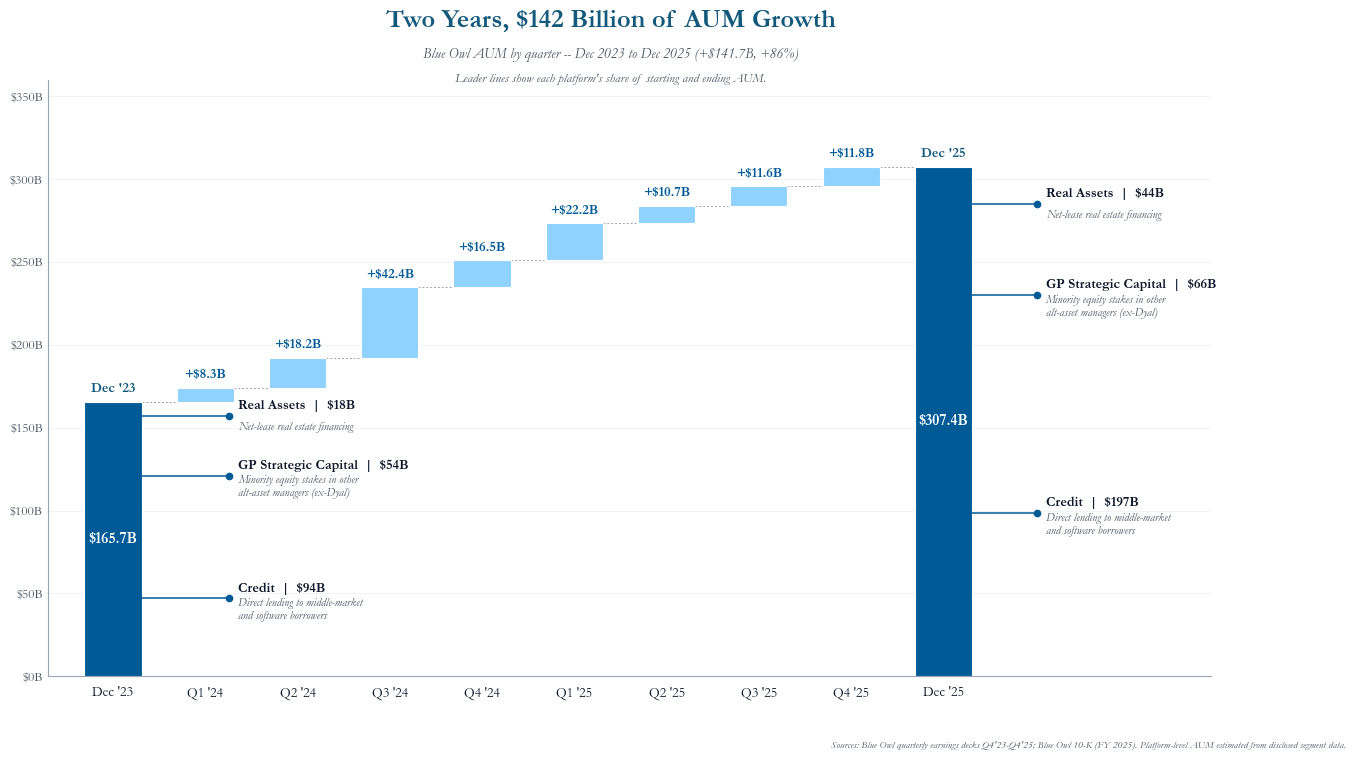

In [8]:
AUM_SERIES = [
    ("Dec '23",  165.7), ("Q1 '24",   174.0), ("Q2 '24",   192.2),
    ("Q3 '24",   234.6), ("Q4 '24",   251.1), ("Q1 '25",   273.3),
    ("Q2 '25",   284.0), ("Q3 '25",   295.6), ("Q4 '25",   307.4),
]
START_LABEL, END_LABEL = "Dec '23", "Dec '25"

PLATFORMS = [
    ("Credit",               "Direct lending to middle-market\nand software borrowers",
     94.0, 197.0, BLUE_DEEP),
    ("GP Strategic Capital", "Minority equity stakes in other\nalt-asset managers (ex-Dyal)",
     54.0,  66.0, BLUE_MAIN),
    ("Real Assets",          "Net-lease real estate financing",
     17.7,  44.4, BLUE_SOFT),
]

start_aum = AUM_SERIES[0][1]; end_aum = AUM_SERIES[-1][1]
deltas = [(AUM_SERIES[i][0], AUM_SERIES[i][1] - AUM_SERIES[i-1][1],
           AUM_SERIES[i-1][1], AUM_SERIES[i][1])
          for i in range(1, len(AUM_SERIES))]

fig, ax = plt.subplots(figsize=(15.0, 7.75))
N_BARS = 1 + len(deltas) + 1
x = list(range(N_BARS)); BAR_W = 0.62
TOTAL_COLOR = BLUE_MAIN; DELTA_COLOR = BLUE_LIGHT

ax.bar(x[0], start_aum, width=BAR_W, color=TOTAL_COLOR, edgecolor="white", linewidth=0.8, zorder=3)
for i, (label, delta, base_level, top) in enumerate(deltas):
    xi = x[1 + i]
    ax.bar(xi, delta, width=BAR_W, bottom=base_level, color=DELTA_COLOR,
           edgecolor="white", linewidth=0.8, zorder=3)
ax.bar(x[-1], end_aum, width=BAR_W, color=TOTAL_COLOR, edgecolor="white", linewidth=0.8, zorder=3)

connector_points = [start_aum]
for (_, _, _, top) in deltas:
    connector_points.append(top)
connector_points.append(end_aum)
for i in range(len(connector_points) - 1):
    y = connector_points[i]
    x_from = x[i] + BAR_W/2; x_to = x[i+1] - BAR_W/2
    ax.plot([x_from, x_to], [y, y], color=GRAY_MID, lw=0.7, linestyle=(0, (2, 2)), zorder=1)

ax.text(x[0], start_aum/2, f"${start_aum:.1f}B",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.text(x[-1], end_aum/2, f"${end_aum:.1f}B",
        ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax.text(x[0], start_aum + 4, "Dec '23",
        ha="center", va="bottom", fontsize=10, color=TITLE_BLUE, fontweight="bold")
ax.text(x[-1], end_aum + 4, "Dec '25",
        ha="center", va="bottom", fontsize=10, color=TITLE_BLUE, fontweight="bold")

for i, (label, delta, base_level, top) in enumerate(deltas):
    xi = x[1 + i]
    ax.text(xi, top + 4, f"+${delta:.1f}B",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color=BLUE_MAIN)

def draw_leader_callouts(bar_x, values, side, names, descriptions):
    bases = []; running = 0.0
    for v in values:
        bases.append(running); running += v
    midpoints = [bases[i] + values[i]/2 for i in range(len(values))]
    if side == "inside-right":
        bar_edge_x = bar_x + BAR_W/2; callout_x = bar_edge_x + 0.95
    else:
        bar_edge_x = bar_x + BAR_W/2; callout_x = bar_edge_x + 0.70
    text_x = callout_x + 0.10
    for mid_y, name, desc, val in zip(midpoints, names, descriptions, values):
        ax.plot([bar_edge_x, callout_x], [mid_y, mid_y],
                color=TOTAL_COLOR, lw=1.1, zorder=4, solid_capstyle="round")
        ax.plot([callout_x], [mid_y], marker="o", markersize=4.5,
                color=TOTAL_COLOR, zorder=5)
        ax.text(text_x, mid_y + 6, f"{name}  |  ${val:.0f}B",
                ha="left", va="center", fontsize=10, fontweight="bold", color=TEXT_MAIN)
        ax.text(text_x, mid_y - 7, desc,
                ha="left", va="center", fontsize=8.5, color=TEXT_MUTED, style="italic")

names = [p[0] for p in PLATFORMS]
descriptions = [p[1] for p in PLATFORMS]
start_values = [p[2] for p in PLATFORMS]
end_values   = [p[3] for p in PLATFORMS]

draw_leader_callouts(bar_x=x[0], values=start_values, side="inside-right",
                     names=names, descriptions=descriptions)
draw_leader_callouts(bar_x=x[-1], values=end_values, side="right",
                     names=names, descriptions=descriptions)

labels = [START_LABEL] + [d[0] for d in deltas] + [END_LABEL]
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10, color=TEXT_MAIN)
ax.tick_params(axis="x", length=0, pad=8)

ax.set_ylim(0, 360)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300, 350])
ax.set_yticklabels([f"${y}B" for y in [0, 50, 100, 150, 200, 250, 300, 350]],
                   fontsize=9.5, color=TEXT_MUTED)
ax.tick_params(axis="y", length=0, pad=4)
ax.spines["left"].set_color(GRAY_MID); ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_color(GRAY_MID); ax.spines["bottom"].set_linewidth(0.8)

for y in [50, 100, 150, 200, 250, 300, 350]:
    ax.axhline(y, color=GRAY_MID, lw=0.4, alpha=0.22, zorder=0)
ax.set_xlim(-0.7, N_BARS + 1.9)

total_change = end_aum - start_aum; pct_change = (end_aum/start_aum - 1) * 100
fig.text(0.5, 0.955, "Two Years, $142 Billion of AUM Growth",
         ha="center", va="center", fontsize=19, fontweight="bold", color=TITLE_BLUE)
fig.text(0.5, 0.912,
         f"Blue Owl AUM by quarter -- Dec 2023 to Dec 2025 (+${total_change:.1f}B, +{pct_change:.0f}%)",
         ha="center", va="center", fontsize=10.5, color=TEXT_MUTED, style="italic")
fig.text(0.5, 0.880, "Leader lines show each platform's share of starting and ending AUM.",
         ha="center", va="center", fontsize=9.5, color=TEXT_MUTED, style="italic")
fig.text(0.99, 0.015,
         "Sources: Blue Owl quarterly earnings decks Q4'23-Q4'25; Blue Owl 10-K (FY 2025). "
         "Platform-level AUM estimated from disclosed segment data.",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 8 -- Where Blue Owl's Revenue Comes From, and Where It Goes

FY 2025 GAAP income statement as a Sankey: $2.87B of revenue (left, by
platform and fee type) flows through one bar (center) into six destinations
(right). Only ~3% of revenue reaches Class A public shareholders after
compensation, G&A, amortization, interest and tax, and the Operating Group's
non-controlling interest.

**Sources**

- Blue Owl 10-K (FY2025), filed Feb 19, 2026.
- Blue Owl Q4 2025 Earnings Deck, Feb 5, 2026.

**Assumptions you can argue with**

The "Interest, tax & other, net" bucket of $150.8M is computed as
interest expense ($163.8M) - other income (~$55.4M) + income tax ($42.4M).
Actual income tax alone is only $42.4M; the remainder is non-operating items
netted in. Labeling it "Interest, tax & other, net" is honest about that
construction.


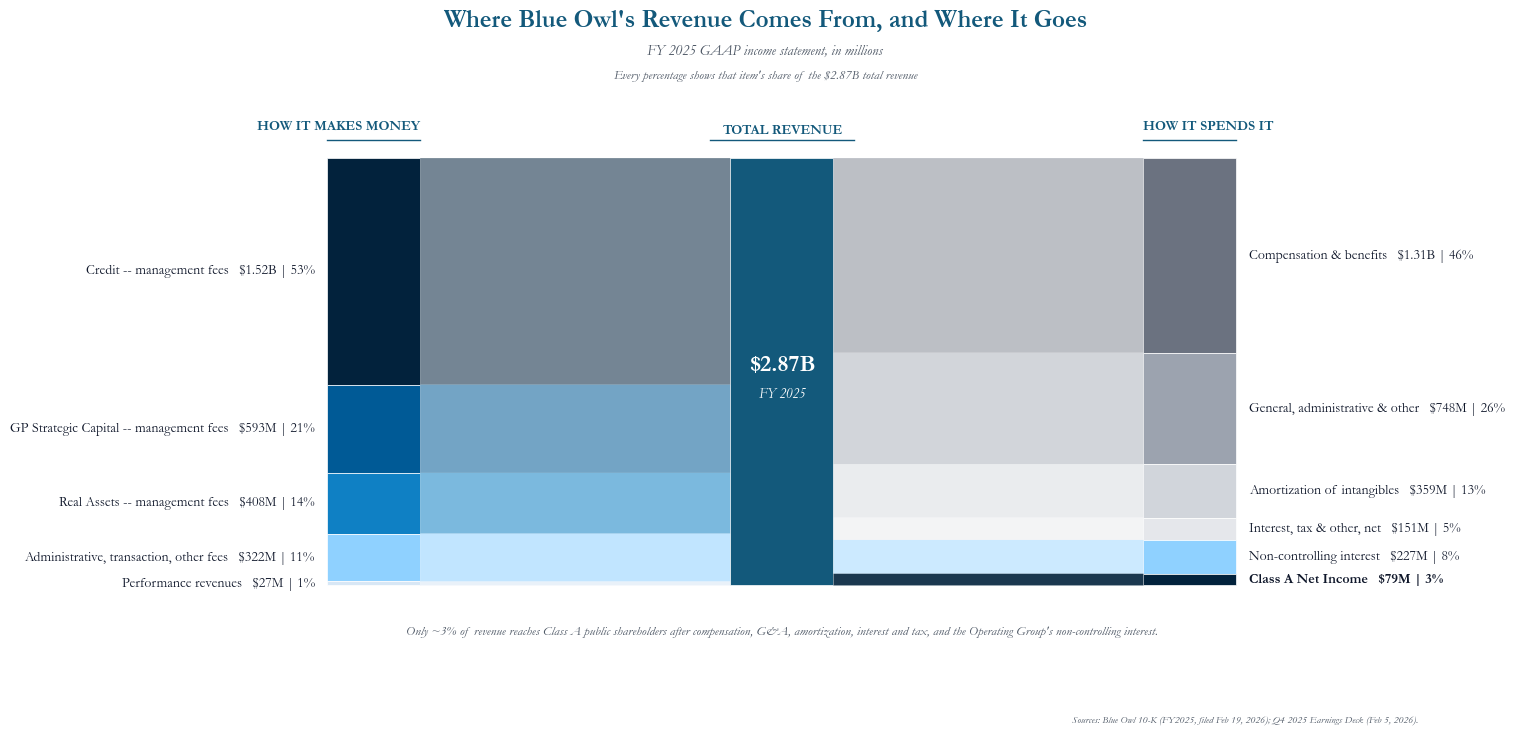

In [9]:
TOTAL_REVENUE = 2870.2

SOURCES_FLOW = [
    ("Credit -- management fees",                   1521.5, BLUE_DEEP),
    ("GP Strategic Capital -- management fees",      592.6, BLUE_MAIN),
    ("Real Assets -- management fees",               407.9, BLUE_SOFT),
    ("Administrative, transaction, other fees",      321.5, BLUE_LIGHT),
    ("Performance revenues",                          26.8, BLUE_MUTED),
]
USES_FLOW = [
    ("Compensation & benefits",          1307.0, GRAY_DARK),
    ("General, administrative & other",   747.9, GRAY_MID),
    ("Amortization of intangibles",       359.0, GRAY_LIGHT),
    ("Interest, tax & other, net",        150.8, "#e5e7eb"),
    ("Non-controlling interest",          226.7, BLUE_LIGHT),
    ("Class A Net Income",                 78.8, BLUE_DEEP),
]

assert abs(sum(v for _, v, _ in SOURCES_FLOW) - TOTAL_REVENUE) < 1.0
assert abs(sum(v for _, v, _ in USES_FLOW) - TOTAL_REVENUE) < 2.0

fig, ax = plt.subplots(figsize=(13.33, 7.50))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_axis_off()

TOP, BOT = 86.0, 12.0; BAND = TOP - BOT
scale = BAND / TOTAL_REVENUE

X_SRC_L, X_SRC_R = 6.0, 15.0
X_MID_L, X_MID_R = 45.0, 55.0
X_USE_L, X_USE_R = 85.0, 94.0

def curve_patch(x0, y0, x1, y1, width, color, alpha=0.55):
    cx1 = x0 + (x1-x0)*0.5; cx2 = x0 + (x1-x0)*0.5
    top = [(MPath.MOVETO, (x0, y0)), (MPath.CURVE4, (cx1, y0)),
           (MPath.CURVE4, (cx2, y1)), (MPath.CURVE4, (x1, y1))]
    bottom = [(MPath.LINETO, (x1, y1-width)), (MPath.CURVE4, (cx2, y1-width)),
              (MPath.CURVE4, (cx1, y0-width)), (MPath.CURVE4, (x0, y0-width)),
              (MPath.CLOSEPOLY, (x0, y0))]
    verts = [v for _, v in top + bottom]; codes = [c for c, _ in top + bottom]
    ax.add_patch(mpatches.PathPatch(MPath(verts, codes), facecolor=color,
                                    edgecolor="none", alpha=alpha))

def node_rect(x0, y_top, width, height, color):
    ax.add_patch(mpatches.Rectangle((x0, y_top - height), width, height,
                                    facecolor=color, edgecolor="white", linewidth=0.5))

src_y = TOP; src_pos = []
for label, value, color in SOURCES_FLOW:
    h = value * scale
    node_rect(X_SRC_L, src_y, X_SRC_R - X_SRC_L, h, color)
    src_pos.append((label, value, src_y, color)); src_y -= h

mid_h = TOTAL_REVENUE * scale; mid_y_top = TOP
node_rect(X_MID_L, mid_y_top, X_MID_R - X_MID_L, mid_h, TITLE_BLUE)

use_y = TOP; use_pos = []
for label, value, color in USES_FLOW:
    h = value * scale
    node_rect(X_USE_L, use_y, X_USE_R - X_USE_L, h, color)
    use_pos.append((label, value, use_y, color)); use_y -= h

mid_in = TOP
for label, value, y_top, color in src_pos:
    h = value * scale
    curve_patch(X_SRC_R, y_top, X_MID_L, mid_in, h, color, alpha=0.55)
    mid_in -= h

mid_out = TOP
for label, value, y_top, color in use_pos:
    h = value * scale
    flow_alpha = 0.45 if label != "Class A Net Income" else 0.90
    curve_patch(X_MID_R, mid_out, X_USE_L, y_top, h, color, alpha=flow_alpha)
    mid_out -= h

def fmt_dollars(v):
    return f"${v/1000:.2f}B" if v >= 1000 else f"${v:,.0f}M"

MIN_LABEL_GAP = 3.4

def resolve_bottom_up(raw, min_gap):
    rev = list(reversed(raw)); resolved_rev = []; last_y = None
    for y_raw, payload in rev:
        y = y_raw if last_y is None else max(y_raw, last_y + min_gap)
        resolved_rev.append((y, payload)); last_y = y
    return list(reversed(resolved_rev))

src_raw = [(y_top - (value*scale)/2, (label, value, y_top, value*scale))
           for label, value, y_top, _ in src_pos]
src_resolved = resolve_bottom_up(src_raw, MIN_LABEL_GAP)
for (y_label, (label, value, y_top, h)) in src_resolved:
    y_bar_mid = y_top - h/2
    pct = value / TOTAL_REVENUE * 100
    if abs(y_label - y_bar_mid) > 0.2:
        ax.plot([X_SRC_L - 0.25, X_SRC_L - 0.5, X_SRC_L - 0.5, X_SRC_L - 0.75],
                [y_bar_mid, y_bar_mid, y_label, y_label],
                color=GRAY_MID, lw=0.6)
    ax.text(X_SRC_L - 1.2, y_label,
            f"{label}   {fmt_dollars(value)} | {pct:.0f}%",
            ha="right", va="center", fontsize=10, color=TEXT_MAIN)

ax.text((X_MID_L + X_MID_R)/2, TOP + 3.8, "TOTAL REVENUE",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color=TITLE_BLUE)
ax.plot([X_MID_L - 2, X_MID_R + 2], [TOP + 3.2, TOP + 3.2], color=TITLE_BLUE, lw=1)
ax.text((X_MID_L + X_MID_R)/2, TOP - mid_h/2 + 1.0, "$2.87B",
        ha="center", va="center", fontsize=17, fontweight="bold", color="white")
ax.text((X_MID_L + X_MID_R)/2, TOP - mid_h/2 - 4.0, "FY 2025",
        ha="center", va="center", fontsize=10, color="white", style="italic")

use_raw = [(y_top - (value*scale)/2, (label, value, y_top, value*scale))
           for label, value, y_top, _ in use_pos]
use_resolved = resolve_bottom_up(use_raw, MIN_LABEL_GAP)
for (y_label, (label, value, y_top, h)) in use_resolved:
    y_bar_mid = y_top - h/2
    pct = value / TOTAL_REVENUE * 100
    weight = "bold" if label == "Class A Net Income" else "normal"
    if abs(y_label - y_bar_mid) > 0.2:
        ax.plot([X_USE_R + 0.25, X_USE_R + 0.5, X_USE_R + 0.5, X_USE_R + 0.75],
                [y_bar_mid, y_bar_mid, y_label, y_label],
                color=GRAY_MID, lw=0.6)
    ax.text(X_USE_R + 1.2, y_label,
            f"{label}   {fmt_dollars(value)} | {pct:.0f}%",
            ha="left", va="center", fontsize=10, color=TEXT_MAIN, fontweight=weight)

fig.text(0.5, 0.955, "Where Blue Owl's Revenue Comes From, and Where It Goes",
         ha="center", va="center", fontsize=18, fontweight="bold", color=TITLE_BLUE)
fig.text(0.5, 0.915, "FY 2025 GAAP income statement, in millions",
         ha="center", va="center", fontsize=10.5, color=TEXT_MUTED, style="italic")
fig.text(0.5, 0.882, "Every percentage shows that item's share of the $2.87B total revenue",
         ha="center", va="center", fontsize=9.5, color=TEXT_MUTED, style="italic")

ax.text(X_SRC_R, TOP + 4.5, "HOW IT MAKES MONEY",
        ha="right", va="bottom", fontsize=10, color=TITLE_BLUE, fontweight="bold")
ax.text(X_USE_L, TOP + 4.5, "HOW IT SPENDS IT",
        ha="left", va="bottom", fontsize=10, color=TITLE_BLUE, fontweight="bold")
ax.plot([X_SRC_L, X_SRC_R], [TOP + 3.2, TOP + 3.2], color=TITLE_BLUE, lw=1)
ax.plot([X_USE_L, X_USE_R], [TOP + 3.2, TOP + 3.2], color=TITLE_BLUE, lw=1)

ax.text(50, 4.0,
        "Only ~3% of revenue reaches Class A public shareholders after compensation, G&A, amortization, interest and tax, and the Operating Group's non-controlling interest.",
        ha="center", va="center", fontsize=9.5, color=TEXT_MUTED, style="italic")
fig.text(0.99, 0.015,
         "Sources: Blue Owl 10-K (FY2025, filed Feb 19, 2026); Q4 2025 Earnings Deck (Feb 5, 2026).",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 9 -- Software / SaaS Concentration

Blue Owl's platform-wide software exposure (~70%) and OTIC's tech-fund mandate
(80%) sit nearly 3x the sector average of ~26%. The dispersion matters because
software borrowers in 2025-26 carry a higher PIK-and-amend rate than the
cross-sector private credit book.

**Sources**

- Morgan Stanley Investment Management, "Semi-Liquid Private Credit: A Quiet
  Revolution." Sector software exposure ~26%.
- Blue Owl Q4 2025 Earnings Deck (Feb 5, 2026). Platform-wide software exposure.
- Blue Owl Technology Income Corp. (OTIC) prospectus, SEC EDGAR CIK 1869453.
  80% technology mandate.
- CNBC, "Blue Owl's Software Lending Triggers Another Quake in Private Credit"
  (Feb 20, 2026).


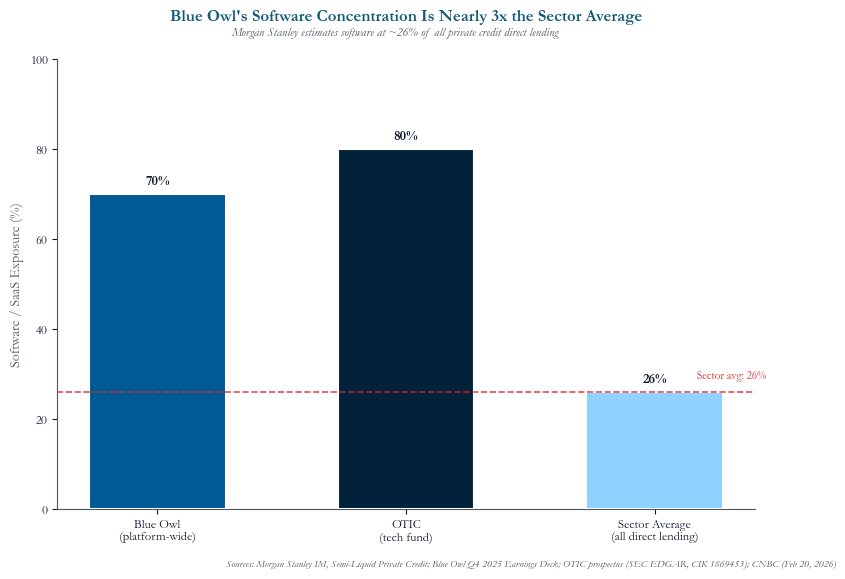

In [10]:
labels = ["Blue Owl\n(platform-wide)", "OTIC\n(tech fund)", "Sector Average\n(all direct lending)"]
values = [70, 80, 26]
colors = [BLUE_MAIN, BLUE_DEEP, BLUE_LIGHT]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels, values, color=colors, width=0.55, edgecolor="white", linewidth=1.5, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color=TEXT_MAIN)

ax.axhline(y=26, color=RED_SOFT, linestyle="--", linewidth=1.2, alpha=0.8, zorder=4)
ax.text(2.45, 29, "Sector avg: 26%", fontsize=8, color=RED_SOFT, ha="right", zorder=5)

ax.set_title("Blue Owl's Software Concentration Is Nearly 3x the Sector Average",
             fontsize=12, fontweight="bold", color=TITLE_BLUE, pad=28)
ax.set_ylabel("Software / SaaS Exposure (%)", fontsize=10, color=TEXT_MUTED)
ax.set_ylim(0, 100); ax.tick_params(axis="both", labelsize=9)

fig.subplots_adjust(top=0.86)
fig.text(0.5, 0.90, "Morgan Stanley estimates software at ~26% of all private credit direct lending",
         ha="center", fontsize=9, color=TEXT_MUTED, style="italic")
fig.text(0.99, 0.01,
         "Sources: Morgan Stanley IM, Semi-Liquid Private Credit; Blue Owl Q4 2025 Earnings Deck; "
         "OTIC prospectus (SEC EDGAR, CIK 1869453); CNBC (Feb 20, 2026)",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 10 -- Blue Owl's Redemption Crisis Escalated in Six Months

Six events in chronological order: 9M 2025 OBDC II baseline ($150M outflows),
Nov 5 2025 merger announced at 0.80x NAV, Nov 19 merger terminated, Feb 18
2026 OBDC II permanently restricted to return-of-capital, Feb 2026 $1.4B
asset sale to fund the closeout, and Q1 2026 total Blue Owl complex
redemption requests of $5.4B. OTIC's request rate hit 40.7% of NAV; OCIC's
hit 21.9%.

**Sources**

- Bloomberg, "Blue Owl Reels as Investors Who Fueled Its Growth Now Want Out"
  (Apr 2, 2026).
- Financial Times, "Blue Owl Struck by $5.4bn of Redemption Requests" (Apr 2026).
- Citywire, "Redemption Requests Top 40% in Blue Owl Private Credit Tech
  Fund" (Apr 2026).
- Blue Owl OCIC 10-K (FY2025, filed Mar 3, 2026; SEC EDGAR CIK 1812554).
- Blue Owl OBDC II Form 8-K Press Release of February 18, 2026 (SEC EDGAR
  CIK 1655887).


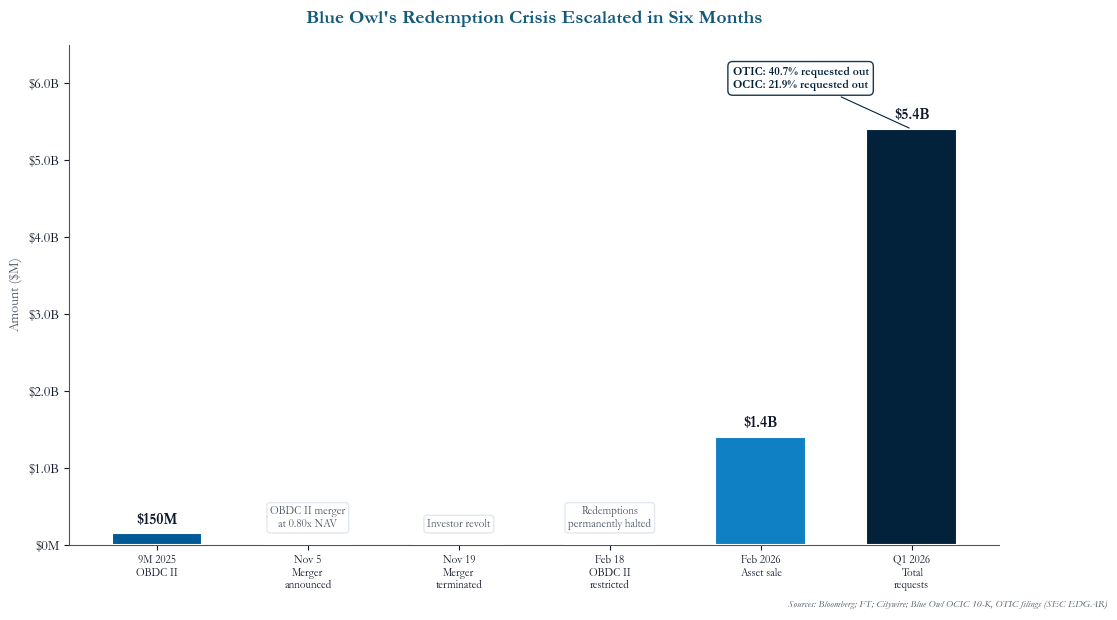

In [11]:
events = [
    ("9M 2025\nOBDC II", 150, ""),
    ("Nov 5\nMerger\nannounced", 0, "OBDC II merger\nat 0.80x NAV"),
    ("Nov 19\nMerger\nterminated", 0, "Investor revolt"),
    ("Feb 18\nOBDC II\nrestricted", 0, "Redemptions\npermanently halted"),
    ("Feb 2026\nAsset sale", 1400, ""),
    ("Q1 2026\nTotal\nrequests", 5400, ""),
]

fig, ax = plt.subplots(figsize=(12, 6.5))
x_pos = list(range(len(events)))
labels = [e[0] for e in events]
amounts = [e[1] for e in events]
notes = [e[2] for e in events]

bars = ax.bar(x_pos, amounts, color=[BLUE_MAIN, BLUE_MUTED, BLUE_MUTED, BLUE_MUTED, BLUE_SOFT, BLUE_DEEP],
              width=0.6, edgecolor="white", linewidth=1.5, zorder=3)

for i, (bar, val) in enumerate(zip(bars, amounts)):
    if val > 0:
        label = f"${val/1000:.1f}B" if val >= 1000 else f"${val}M"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                label, ha="center", va="bottom", fontsize=11, fontweight="bold", color=TEXT_MAIN)

for i, (_, val, note) in enumerate(events):
    if val == 0 and note:
        ax.annotate(note, xy=(i, 200), fontsize=8, color=TEXT_MUTED,
                    ha="center", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e2e8f0"))

ax.annotate("OTIC: 40.7% requested out\nOCIC: 21.9% requested out",
            xy=(5, 5400), xytext=(-80, 30), textcoords="offset points",
            fontsize=8.5, color=BLUE_DEEP, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="-", color=BLUE_DEEP, lw=0.8),
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=BLUE_DEEP, alpha=0.9))

ax.set_title("Blue Owl's Redemption Crisis Escalated in Six Months",
             fontsize=14, fontweight="bold", color=TITLE_BLUE, pad=16)
ax.set_ylabel("Amount ($M)", fontsize=10, color=TEXT_MUTED)
ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=8, ha="center")
ax.set_ylim(0, 6500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.1f}B" if x >= 1000 else f"${x:.0f}M"))
fig.text(0.99, 0.01, "Sources: Bloomberg; FT; Citywire; Blue Owl OCIC 10-K, OTIC filings (SEC EDGAR)",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 11 -- OWL Has Never Sustainably Traded Above Its SPAC Valuation

OWL stock price from May 2021 (SPAC listing at $10.50) through April 2026.
Annotated with five inflection points. The stock briefly cleared $25 in
January 2025; by April 2026 it traded at $8.57, down 66% from ATH and below
the SPAC baseline.

**Sources**

- Yahoo Finance / Bloomberg. OWL monthly closes, May 2021 through April 2026.
- Blue Owl Capital Investor Relations.

**Note on resolution**

Monthly close prices are simplified for clarity. The actual daily OWL series
shows the same path with more noise; the monthly version is sufficient for
the structural point.


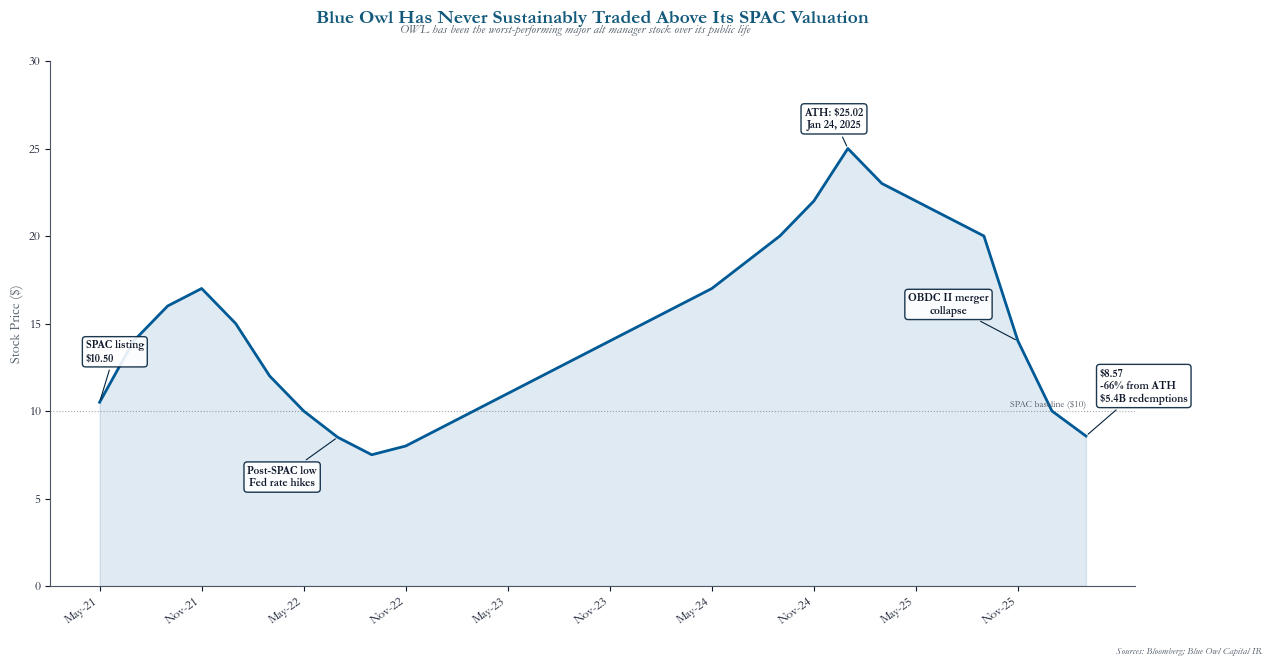

In [12]:
dates = [
    "May-21", "Jul-21", "Sep-21", "Nov-21", "Jan-22", "Mar-22", "May-22", "Jul-22",
    "Sep-22", "Nov-22", "Jan-23", "Mar-23", "May-23", "Jul-23", "Sep-23", "Nov-23",
    "Jan-24", "Mar-24", "May-24", "Jul-24", "Sep-24", "Nov-24", "Jan-25", "Mar-25",
    "May-25", "Jul-25", "Sep-25", "Nov-25", "Jan-26", "Mar-26"
]
prices = [
    10.5, 14, 16, 17, 15, 12, 10, 8.5,
    7.5, 8, 9, 10, 11, 12, 13, 14,
    15, 16, 17, 18.5, 20, 22, 25, 23,
    22, 21, 20, 14, 10, 8.57
]

fig, ax = plt.subplots(figsize=(14, 7))
x = list(range(len(dates)))
ax.fill_between(x, prices, alpha=0.12, color=BLUE_MAIN)
ax.plot(x, prices, color=BLUE_MAIN, linewidth=2, zorder=3)

events6 = [
    (0, 10.5, "SPAC listing\n$10.50", (-10, 30), "left"),
    (7, 8.5, "Post-SPAC low\nFed rate hikes", (-40, -35), "center"),
    (22, 25, "ATH: $25.02\nJan 24, 2025", (-10, 15), "center"),
    (27, 14, "OBDC II merger\ncollapse", (-50, 20), "center"),
    (29, 8.57, "$8.57\n-66% from ATH\n$5.4B redemptions", (10, 25), "left"),
]
for xi, yi, txt, offset, ha in events6:
    ax.annotate(txt, xy=(xi, yi), xytext=offset, textcoords="offset points",
                fontsize=8, color=TEXT_MAIN, ha=ha, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=BLUE_DEEP, lw=0.8),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=BLUE_DEEP, alpha=0.9))

ax.axhline(y=10, color=TEXT_MUTED, linestyle=":", linewidth=0.8, alpha=0.5)
ax.text(len(dates)-1, 10.3, "SPAC baseline ($10)", fontsize=7, color=TEXT_MUTED, ha="right")

ax.set_title("Blue Owl Has Never Sustainably Traded Above Its SPAC Valuation",
             fontsize=14, fontweight="bold", color=TITLE_BLUE, pad=28)
ax.set_ylabel("Stock Price ($)", fontsize=10, color=TEXT_MUTED)
ax.set_xticks(range(0, len(dates), 3))
ax.set_xticklabels([dates[i] for i in range(0, len(dates), 3)], fontsize=8, rotation=35, ha="right")
ax.set_ylim(0, 30); ax.tick_params(axis="both", labelsize=9)

fig.subplots_adjust(top=0.86)
fig.text(0.5, 0.90, "OWL has been the worst-performing major alt manager stock over its public life",
         ha="center", fontsize=9.5, color=TEXT_MUTED, style="italic")
fig.text(0.99, 0.01, "Sources: Bloomberg; Blue Owl Capital IR",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Chart 12 -- Q1 2026 Multi-Sponsor Redemption Pressure

Six non-traded BDCs in Q1 2026: requested vs honored redemptions as a percent
of NAV. Five hit the prospectus 5% cap. Only Blackstone's BCRED met every
request, after upsizing its cap to 7% and injecting $400M of sponsor capital.

**Sources**

- PitchBook, "Blue Owl holds BDC withdrawals at 5% after redemption requests
  of 41%, 22%" (April 2026). OTIC and OCIC.
- Bloomberg, "Ares Limits Private Credit Fund Withdrawals" (Mar 24, 2026). ASIF.
- Bloomberg, "Apollo Caps Private Credit Fund Withdrawals" (Mar 23, 2026). ADS.
- WithIntelligence, "What is actually going on in BDC portfolios?" (2026). HLEND.
- Bisnow / GlobeSt, "Blackstone Answers Redemption Spike with Higher Tender,
  Fresh Capital" (Mar 2026). BCRED.

**Note on the dollar amounts**

Combined OTIC + OCIC Q1 2026 redemption requests were ~$5.4B per Reuters and CNBC. The percentages each non-traded BDC reports are of NAV, but the dollar denominator can shift across funds depending on whether AUM, NAV, or redeemable share class is used. OCIC's ~$2.9B reflects the $5.4B Blue Owl total minus OTIC's $2.5B.

**Note on the cap**

The 5% quarterly cap is set by each fund's share repurchase program in its
prospectus, not by ICA §23(c) directly. §23(c) is the statutory authority
that allows tender offers; the cap itself is fund-level disclosure.


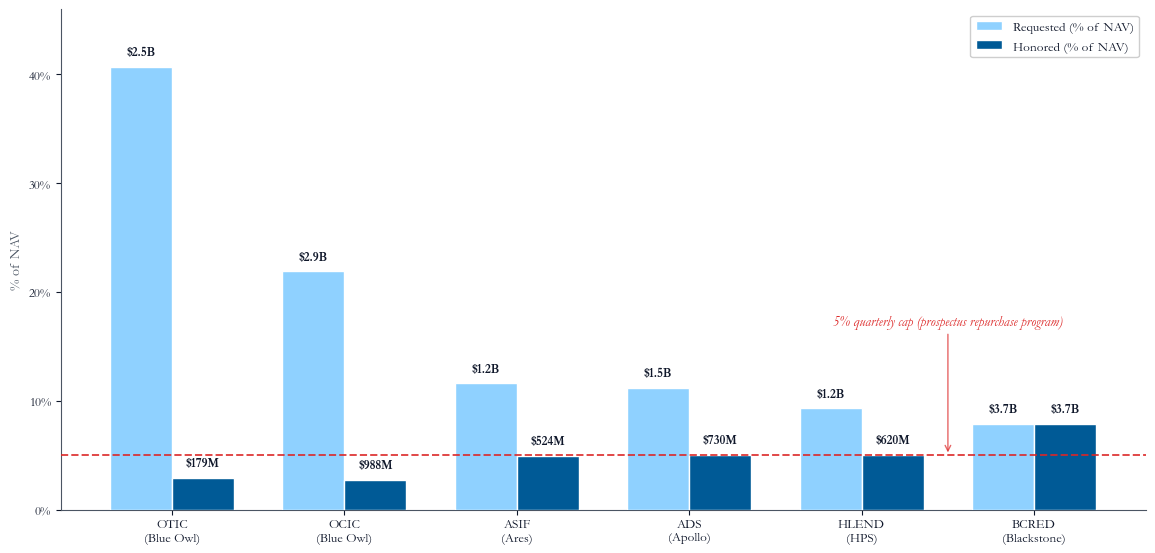

In [13]:
funds7 = [
    "OTIC\n(Blue Owl)", "OCIC\n(Blue Owl)", "ASIF\n(Ares)",
    "ADS\n(Apollo)", "HLEND\n(HPS)", "BCRED\n(Blackstone)",
]
requested7 = [40.7, 21.9, 11.6, 11.2, 9.3, 7.9]
honored7   = [2.9,  2.7,  4.9,  5.0,  5.0, 7.9]
requested_dollars = ["$2.5B", "$2.9B", "$1.2B", "$1.5B", "$1.2B", "$3.7B"]
honored_dollars   = ["$179M", "$988M", "$524M", "$730M", "$620M", "$3.7B"]

fig, ax = plt.subplots(figsize=(14, 6.5))
x = np.arange(len(funds7)); width = 0.36

bars_req = ax.bar(x - width/2, requested7, width, label="Requested (% of NAV)",
                  color=BLUE_LIGHT, edgecolor="white", linewidth=1, zorder=3)
bars_hon = ax.bar(x + width/2, honored7, width, label="Honored (% of NAV)",
                  color=BLUE_MAIN, edgecolor="white", linewidth=1, zorder=3)

ax.axhline(y=5, color=RED_SOFT, linestyle="--", linewidth=1.4, alpha=0.85, zorder=4)
ax.annotate("5% quarterly cap (prospectus repurchase program)",
    xy=(4.5, 5), xytext=(4.5, 17),
    fontsize=10, color=RED_SOFT, fontweight="bold", ha="center", style="italic",
    arrowprops=dict(arrowstyle="->", color=RED_SOFT, lw=1, alpha=0.7, shrinkA=2, shrinkB=2),
    zorder=5,
)

for bar, dollars in zip(bars_req, requested_dollars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, dollars,
            ha="center", va="bottom", fontsize=9, color=TEXT_MAIN, fontweight="bold")
for bar, dollars in zip(bars_hon, honored_dollars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, dollars,
            ha="center", va="bottom", fontsize=9, color=TEXT_MAIN, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(funds7, fontsize=9.5)
ax.set_ylabel("% of NAV", fontsize=10, color=TEXT_MUTED)
ax.set_ylim(0, 46)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.95)
ax.tick_params(axis="y", labelsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.show()


---

## Chart 13 -- BREIT vs Blue Owl: A Counterexample

Three-panel comparison. BREIT (Blackstone Real Estate Income Trust) faced
its own redemption stress in Jan 2023 with peak monthly outflows of 7.6% of
NAV on a ~$70B fund. Blackstone (the sponsor) absorbed that pressure: UC
Regents committed $4.0B to a strategic venture, and Blackstone honored every
quarterly tender. Blue Owl's redemption pressure in Q1 2026 was 5x larger
in percent terms, on a similar-scale fund family, and the sponsor injected
no external capital.

**Sources**

- Blackstone, UC Investments Strategic Venture press release (Jan 3, 2023).
- Bisnow, "BREIT Fulfills All Redemption Requests For First Time Since 2022"
  (Mar 2024).
- InvestmentNews, "Blackstone REIT Hits Key Milestone, Lifts Redemption Limit."
- Blackstone Q4 2022 / Q4 2023 / Q4 2024 / Q4 2025 Earnings Press Releases.
- Blue Owl Q4 2025 Earnings Deck. Platform AUM at Dec 2025.
- Citywire, FT, Bloomberg coverage of Q1 2026 OTIC / OCIC redemption requests.


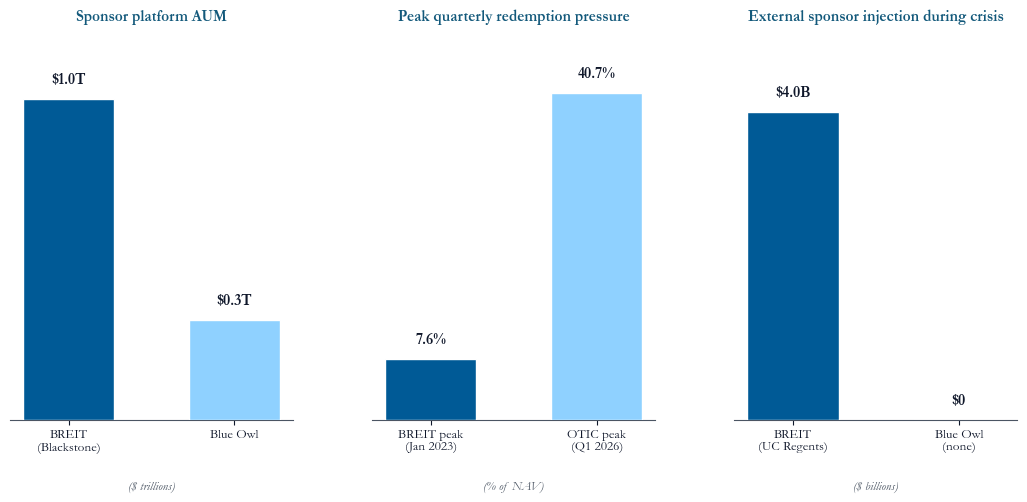

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2))

panels = [
    {
        "title": "Sponsor platform AUM", "unit": "($ trillions)",
        "labels": ["BREIT\n(Blackstone)", "Blue Owl"],
        "values": [1.0, 0.31], "display": ["$1.0T", "$0.3T"],
        "colors": [BLUE_MAIN, BLUE_LIGHT], "ylim": 1.2,
    },
    {
        "title": "Peak quarterly redemption pressure", "unit": "(% of NAV)",
        "labels": ["BREIT peak\n(Jan 2023)", "OTIC peak\n(Q1 2026)"],
        "values": [7.6, 40.7], "display": ["7.6%", "40.7%"],
        "colors": [BLUE_MAIN, BLUE_LIGHT], "ylim": 48,
    },
    {
        "title": "External sponsor injection during crisis", "unit": "($ billions)",
        "labels": ["BREIT\n(UC Regents)", "Blue Owl\n(none)"],
        "values": [4.0, 0.0], "display": ["$4.0B", "$0"],
        "colors": [BLUE_MAIN, BLUE_LIGHT], "ylim": 5.0,
    },
]

for ax, panel in zip(axes, panels):
    x = np.arange(len(panel["labels"]))
    bars = ax.bar(x, panel["values"], width=0.55,
                  color=panel["colors"], edgecolor="white", linewidth=1, zorder=3)
    for bar, label in zip(bars, panel["display"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + panel["ylim"] * 0.03,
                label, ha="center", va="bottom",
                fontsize=11, color=TEXT_MAIN, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(panel["labels"], fontsize=9.5, color=TEXT_MAIN)
    ax.set_ylim(0, panel["ylim"]); ax.set_yticks([])
    ax.spines["left"].set_visible(False); ax.spines["bottom"].set_color(TEXT_MUTED)
    ax.set_title(panel["title"], fontsize=11, fontweight="bold", color=TITLE_BLUE, pad=10)
    ax.text(0.5, -0.18, panel["unit"], transform=ax.transAxes,
            ha="center", fontsize=9, color=TEXT_MUTED, style="italic")

fig.subplots_adjust(top=0.92, bottom=0.18, wspace=0.28)
plt.show()


---

## Chart 14 -- The Regulatory Gap: Banks vs Private Credit

Eleven prudential and disclosure dimensions. Banks above $250B in assets
satisfy each one through statute, supervisory regime, or industry standard.
Private credit at $300B+ AUM satisfies most of them either not at all or
only minimally, often through fund-level prospectus disclosure rather than
statute or examination.

**Sources**

- Federal Reserve FEDS Notes, "Private Credit: Characteristics and Risks"
  (Feb 23, 2024).
- National Association of Private Fund Managers v. SEC, No. 23-60471 (5th
  Cir., Jun 5, 2024). Vacated the SEC Private Fund Advisers Rule in full.
- EU Directive 2024/927 (AIFMD II). Loan-origination rules and leverage
  limits taking effect April 16, 2026.
- Blue Owl OBDC, OCIC, OTIC SEC EDGAR filings.

**Assumptions you can argue with**
1. Scoring is binary-leaning (Yes / Minimal / No) with one partial level.
   Reasonable people could put "Standardized disclosure" higher for private
   credit (registered BDCs do file 10-Ks) or lower for banks (Pillar 3
   disclosures vary).
2. The bank column reflects post-Dodd-Frank Cat I-III tailoring. Cat IV
   banks ($100-250B) face a lighter regime; this chart uses the >$250B
   cohort as the reference point.


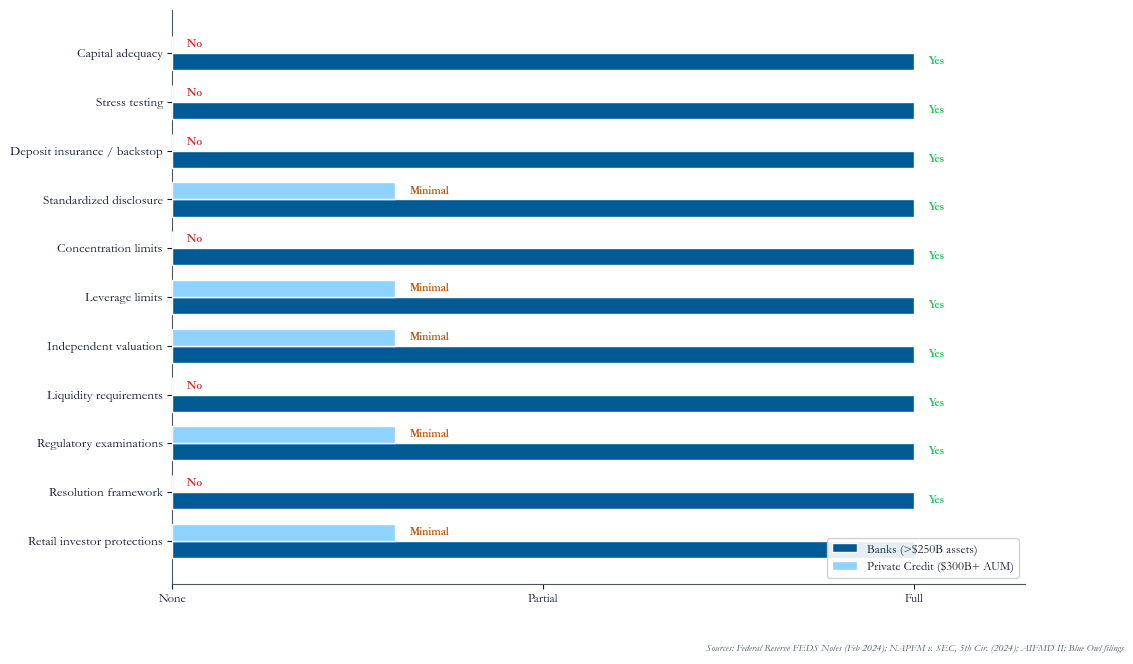

In [15]:
requirements = [
    "Capital adequacy",
    "Stress testing",
    "Deposit insurance / backstop",
    "Standardized disclosure",
    "Concentration limits",
    "Leverage limits",
    "Independent valuation",
    "Liquidity requirements",
    "Regulatory examinations",
    "Resolution framework",
    "Retail investor protections",
]
banks = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
pc    = [0, 0, 0, 0.3, 0, 0.3, 0.3, 0, 0.3, 0, 0.3]

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(requirements)); height = 0.35

ax.barh(y + height/2, banks, height, label="Banks (>$250B assets)",
        color=BLUE_MAIN, edgecolor="white", linewidth=1, zorder=3)
ax.barh(y - height/2, pc, height, label="Private Credit ($300B+ AUM)",
        color=BLUE_LIGHT, edgecolor="white", linewidth=1, zorder=3)

ax.set_yticks(y); ax.set_yticklabels(requirements, fontsize=9.5)
ax.set_xlim(0, 1.15); ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(["None", "Partial", "Full"], fontsize=9)
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
fig.subplots_adjust(top=0.93)

for i, (b, p) in enumerate(zip(banks, pc)):
    ax.text(b + 0.02, i + height/2, "Yes", fontsize=8, color=GREEN, va="center", fontweight="bold")
    label = "No" if p == 0 else "Minimal"
    color = RED_SOFT if p == 0 else "#b45309"
    ax.text(max(p, 0) + 0.02, i - height/2, label, fontsize=8, color=color, va="center", fontweight="bold")

fig.text(0.99, 0.01, "Sources: Federal Reserve FEDS Notes (Feb 2024); NAPFM v. SEC, 5th Cir. (2024); AIFMD II; Blue Owl filings",
         ha="right", va="bottom", fontsize=7.5, color=TEXT_MUTED, style="italic")
plt.show()


---

## Sources

A consolidated, curated bibliography for the post (per-chart sources, plus
the most load-bearing references behind the written narrative) lives in the
companion notebook:

- `Blue_Owl_Sources.ipynb`

If you want the full source set used during research, that lives in the
private working folder and is summarized in the curated bibliography.

---

*Companion data for "The Case for Regulating Private Credit." Released under
MIT for code, CC-BY-4.0 for data and prose. Attribute Mohammad Ahmadi /
Ahmadi Research and link back to the post.*
